In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# Load your dataset
df = pd.read_csv('combined-1.csv')

# Count rows with labels 0 and 1 before filtering
count_0 = len(df[df['label'] == 0])
count_1 = len(df[df['label'] == 1])
print(f'Number of rows with label 0: {count_0}')
print(f'Number of rows with label 1: {count_1}')

# Filter out rows where the label is 0 or 1
df_filtered = df[~df['label'].isin([0, 1])]

print(f'Remaining rows after filtering: {len(df_filtered)}')
display(df_filtered.head())

Number of rows with label 0: 36
Number of rows with label 1: 8
Remaining rows after filtering: 209649


,label,rho,tau_pt,tau_eta,tau_mass,tau_E_over_pt,tau_charge,tau_n_charged_prongs,tau_n_neutral_prongs,chargedIsoPtSum,...,tau_pt_weighted_deta_strip,tau_pt_weighted_dphi_strip,tau_pt_weighted_dr_signal,tau_pt_weighted_dr_iso,tau_leadingTrackNormChi2,tau_gj_angle_diff_valid,tau_gj_angle_diff,tau_n_photons,tau_emFraction,tau_inside_ecal_crack
0,2,3.629412,36.845631,-1.091423,0.877568,1.657295,1,3,0,0.000000,...,0.000000,0.000000,0.012683,0.070144,1,1,0.002592,0,1.0,0
1,2,6.598049,50.110668,-1.187409,0.139570,1.791795,1,1,0,0.000000,...,0.054829,0.094678,0.009889,0.346652,1,0,0.000000,2,1.0,0
2,3,6.598049,27.066107,1.744331,1.263521,2.948786,1,2,1,10.384300,...,0.037350,0.056044,0.068836,0.287238,0,0,0.000000,3,1.0,0
3,2,11.472245,38.093441,-1.259100,0.139570,1.903082,1,1,0,0.000000,...,0.000000,0.000000,0.000055,0.399704,1,0,0.000000,0,1.0,0
4,3,10.760911,25.480967,-1.360224,1.003346,2.077208,1,3,0,6.189421,...,0.000000,0.000000,0.022735,0.248804,1,1,3.112640,0,1.0,0


In [ ]:
df = df_filtered.copy()

# 1. Map labels: 2 (Tau) -> 1, 3 (QCD) -> 0
label_mapping = {2: 1, 3: 0}
df['label'] = df['label'].map(label_mapping)

# Randomly shuffle the rows
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# 2. Separate features (X) and target (y)
y = df['label']
X = df.drop(columns=['label'])

print(f'Dataset shuffled. Shape: {df.shape}')



# SPLITTING INTO TRAIN,VALIDATION,TEST 70/15/15

from sklearn.model_selection import train_test_split

# Split into Train (70%) and Remainder (30%)
X_train, X_rem, y_train, y_rem = train_test_split(X, y, train_size=0.7, random_state=42, stratify=y)

# Split Remainder into Validation (15% total) and Test (15% total)
# Since the remainder is 30% of the total, we split it 50/50
X_val, X_test, y_val, y_test = train_test_split(X_rem, y_rem, test_size=0.5, random_state=42, stratify=y_rem)

print(f'Train set shape: {X_train.shape}')
print(f'Validation set shape: {X_val.shape}')
print(f'Test set shape: {X_test.shape}')

Dataset shuffled. Shape: (209649, 41)
Train set shape: (146754, 40)
Validation set shape: (31447, 40)
Test set shape: (31448, 40)


In [ ]:
display(X.head(),y.head(), y.shape)

,rho,tau_pt,tau_eta,tau_mass,tau_E_over_pt,tau_charge,tau_n_charged_prongs,tau_n_neutral_prongs,chargedIsoPtSum,chargedIsoPtSumdR03_over_dR05,...,tau_pt_weighted_deta_strip,tau_pt_weighted_dphi_strip,tau_pt_weighted_dr_signal,tau_pt_weighted_dr_iso,tau_leadingTrackNormChi2,tau_gj_angle_diff_valid,tau_gj_angle_diff,tau_n_photons,tau_emFraction,tau_inside_ecal_crack
0,11.534082,23.081053,1.264731,0.379892,1.912299,1,1,1,0.569499,2.641612,...,0.019163,0.030922,0.018006,0.250757,2,0,0.0,4,1.0,0
1,14.338047,44.833248,0.653353,3.410543,1.223504,-1,1,1,0.000000,0.000000,...,0.065718,0.106472,0.035895,0.386623,2,0,0.0,7,1.0,0
2,11.126439,82.679848,1.592636,0.414070,2.560045,-1,1,1,0.000000,0.000000,...,0.000766,0.006789,0.006145,0.000000,0,0,0.0,2,1.0,0
3,6.872455,40.148968,-1.265914,0.888678,1.914285,1,2,1,12.511386,0.921895,...,0.057811,0.085179,0.081152,0.181702,0,0,0.0,15,1.0,0
4,7.186014,24.117498,-1.971638,0.767154,3.660968,-1,2,0,1.627989,0.000000,...,0.000000,0.000000,0.017705,0.071280,0,0,0.0,0,1.0,0


,label
0,1
1,1
2,1
3,0
4,0


(209649,)

In [ ]:
# 1. Features with highly skewed, exponential tails requiring log transform
log_features = [
    'rho',
    'tau_pt',
    'chargedIsoPtSum',
    'neutralIsoPtSum',
    'photonPtSumOutsideSignalCone',
    'puCorrPtSum'
]

# 2. Boolean/Detector Logic Flags (Must remain strict 0 or 1)
boolean_features = [
    'tau_dxy_valid',
    'tau_ip3d_valid',
    'tau_dz_sig_valid',
    'tau_gj_angle_diff_valid',
    'tau_inside_ecal_crack'
]

# 3. Continuous Variables (Direct Standard Scaling)
continuous_features = [
    'tau_eta', 'tau_mass', 'tau_E_over_pt', 'tau_charge',
    'tau_n_charged_prongs', 'tau_n_neutral_prongs', 'tau_n_photons',
    'chargedIsoPtSumdR03_over_dR05', 'footprintCorrection',
    'neutralIsoPtSumWeight_over_neutralIsoPtSum',
    'neutralIsoPtSumWeightdR03_over_neutralIsoPtSum',
    'neutralIsoPtSumdR03_over_dR05', 'tau_emFraction',
    'tau_dxy', 'tau_dxy_sig', 'tau_ip3d', 'tau_ip3d_sig', 'tau_dz', 'tau_dz_sig',
    'tau_flightLength_x', 'tau_flightLength_y', 'tau_flightLength_z', 'tau_flightLength_sig',
    'tau_pt_weighted_deta_strip', 'tau_pt_weighted_dphi_strip',
    'tau_pt_weighted_dr_signal', 'tau_pt_weighted_dr_iso',
    'tau_leadingTrackNormChi2', 'tau_gj_angle_diff'
]

# Combine log and continuous features for the scaler later
features_to_scale = log_features + continuous_features

In [ ]:
# Create clean copies to avoid pandas warnings
X_train_proc = X_train.copy()
X_val_proc = X_val.copy()
X_test_proc = X_test.copy()


# logarithmic scaling
# Apply log1p safely (ln(x + 1))
for col in log_features:
    X_train_proc[col] = np.log1p(X_train_proc[col])
    X_val_proc[col] = np.log1p(X_val_proc[col])
    X_test_proc[col] = np.log1p(X_test_proc[col])

print("Logarithmic compression applied.")


# linear scaling
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()

# Fit ONLY on the training set, and instantly transform it
X_train_proc[features_to_scale] = scaler.fit_transform(X_train_proc[features_to_scale])

# Transform validation and test sets using the training baseline
X_val_proc[features_to_scale] = scaler.transform(X_val_proc[features_to_scale])
X_test_proc[features_to_scale] = scaler.transform(X_test_proc[features_to_scale])

print("Standard scaling completed. Boolean flags were bypassed.")

Logarithmic compression applied.
Standard scaling completed. Boolean flags were bypassed.


In [ ]:
# Reorder the columns to ensure consistency (Scaled Features -> Boolean Flags)
final_column_order = features_to_scale + boolean_features

X_train_proc = X_train_proc[final_column_order]
X_val_proc = X_val_proc[final_column_order]
X_test_proc = X_test_proc[final_column_order]

# Convert to NumPy arrays for TensorFlow
X_train_tensor = X_train_proc.to_numpy()
X_val_tensor = X_val_proc.to_numpy()
X_test_tensor = X_test_proc.to_numpy()

# Ensure labels are also numpy arrays
y_train_tensor = y_train.to_numpy()
y_val_tensor = y_val.to_numpy()
y_test_tensor = y_test.to_numpy()

print(f"Final Training Tensor Shape: {X_train_tensor.shape}")
print(f"Final Validation Tensor Shape: {X_val_tensor.shape}")
print(f"Final Test Tensor Shape: {X_test_tensor.shape}")

display(X_train_proc.head())

Final Training Tensor Shape: (146754, 40)
Final Validation Tensor Shape: (31447, 40)
Final Test Tensor Shape: (31448, 40)


,rho,tau_pt,chargedIsoPtSum,neutralIsoPtSum,photonPtSumOutsideSignalCone,puCorrPtSum,tau_eta,tau_mass,tau_E_over_pt,tau_charge,...,tau_pt_weighted_dphi_strip,tau_pt_weighted_dr_signal,tau_pt_weighted_dr_iso,tau_leadingTrackNormChi2,tau_gj_angle_diff,tau_dxy_valid,tau_ip3d_valid,tau_dz_sig_valid,tau_gj_angle_diff_valid,tau_inside_ecal_crack
76366,-0.999307,0.315336,-0.756607,-1.116744,0.999013,-1.505871,-0.109338,-0.866182,-0.882953,-1.004658,...,0.589185,-0.005456,2.066506,0.287296,-0.428502,1,1,1,0,0
135780,0.388314,4.872716,-1.222380,-1.116744,0.406334,0.196919,-0.714263,-0.052710,-0.515327,0.995364,...,-0.573004,-1.171801,-1.649020,-0.201265,-0.428502,1,1,1,0,0
178127,0.651308,-0.686403,-0.471648,-1.116744,1.217262,-0.098177,-1.178213,-1.703260,0.245930,-1.004658,...,1.283388,0.506907,1.347779,0.043015,-0.428502,1,1,1,0,0
182794,0.882501,-0.738081,0.103090,0.290371,0.969631,0.851701,-0.268162,1.835254,-0.838766,0.995364,...,0.926663,2.254971,0.637001,-0.201265,-0.428502,1,1,1,0,0
204471,-1.161439,0.309552,-1.222380,-1.116744,1.107356,-0.228991,1.538831,0.954427,1.305091,0.995364,...,0.617292,-0.113619,-1.649020,-0.201265,-0.428502,1,1,1,0,0


In [ ]:
# 1. Base Kinematics (Phase Space & Multiplicity)
features_A = [
    'tau_pt', 'tau_eta', 'tau_mass', 'tau_E_over_pt', 'tau_charge',
    'tau_n_charged_prongs', 'tau_n_neutral_prongs', 'tau_n_photons'
]

# 2. Vertexing (Adding Secondary Vertex Displacements)
features_B = features_A + [
    'tau_ip3d_sig', 'tau_dxy_sig', 'tau_dz_sig', 'tau_flightLength_sig'
]

# 3. Isolation (Adding Spatial Energy Gradients)
features_C = features_B + [
    'chargedIsoPtSum', 'neutralIsoPtSum', 'puCorrPtSum',
    'tau_pt_weighted_dr_signal', 'tau_pt_weighted_dr_iso'
]

# 4. Full High-Level Variables (All 40 Processed Features)
# We use the final_column_order list generated during your preprocessing step
features_D = final_column_order

# Dictionary mapping for our training loop
model_configs = {
    'Kinematics Only': features_A,
    '+ Tracking/Vertexing': features_B,
    '+ Isolation/Energy': features_C,
    'Full Feature Suite': features_D
}

In [ ]:
import tensorflow as tf
from sklearn.metrics import roc_curve, auc
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

def train_ablation_model(feature_list, model_name):
    print(f"Initializing {model_name} | Input Dimensions: {len(feature_list)} features")

    # 1. Slice the DataFrames and convert to tensors
    X_train_slice = X_train_proc[feature_list].to_numpy()
    X_val_slice = X_val_proc[feature_list].to_numpy()
    X_test_slice = X_test_proc[feature_list].to_numpy()

    # 2. Build the Model Architecture dynamically
    model = Sequential([
        Input(shape=(len(feature_list),)),
        Dense(128, activation='swish', kernel_initializer='he_normal'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(64, activation='swish', kernel_initializer='he_normal'),
        BatchNormalization(),
        Dropout(0.2),
        Dense(32, activation='swish', kernel_initializer='he_normal'),
        BatchNormalization(),
        Dropout(0.2),
        Dense(16, activation='swish', kernel_initializer='he_normal'),
        BatchNormalization(),
        Dense(1, activation='sigmoid')
    ])

    # --- FULL METRIC SUITE INJECTED HERE ---
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            tf.keras.metrics.AUC(name='auc'),
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall')
        ]
    )

    # 3. Initialize FRESH Callbacks for this specific model run
    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1
    )

    lr_scheduler = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    )

    local_callbacks_list = [early_stopping, lr_scheduler]

    # 4. Execute Training
    print(f"--> Training {model_name}...")
    model.fit(
        X_train_slice, y_train_tensor,
        epochs=100, batch_size=1024,
        validation_data=(X_val_slice, y_val_tensor),
        callbacks=local_callbacks_list,
        verbose=0 # Keeps the notebook clean from epoch spam
    )

    # 5. Extract and Print Full Metrics on the Test Set
    test_results = model.evaluate(X_test_slice, y_test_tensor, verbose=0)

    print(f"--> Completed {model_name}! Final Test Metrics:")
    for metric_name, value in zip(model.metrics_names, test_results):
        print(f"    {metric_name.capitalize()}: {value:.4f}")
    print("\n")

    # 6. Extract ROC Coordinates for the plotting dictionary
    y_pred = model.predict(X_test_slice, verbose=0).ravel()
    fpr, tpr, _ = roc_curve(y_test_tensor, y_pred)
    model_auc = auc(fpr, tpr)

    return fpr, tpr, model_auc

In [ ]:
# Dictionary to store the mathematical coordinates of each curve
roc_results = {}

print("==========================================")
print("COMMENCING ABLATION STUDY TRAINING")
print("==========================================\n")

for name, features in model_configs.items():
    fpr, tpr, model_auc = train_ablation_model(features, name)
    roc_results[name] = {'fpr': fpr, 'tpr': tpr, 'auc': model_auc}

COMMENCING ABLATION STUDY TRAINING

Initializing Kinematics Only | Input Dimensions: 8 features
--> Training Kinematics Only...

Epoch 33: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 40: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 48: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 56: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.

Epoch 61: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.

Epoch 66: ReduceLROnPlateau reducing learning rate to 1.5625000742147677e-05.
Epoch 66: early stopping
Restoring model weights from the end of the best epoch: 51.
--> Completed Kinematics Only! Final Test Metrics:
    Loss: 0.4050
    Compile_metrics: 0.8103


Initializing + Tracking/Vertexing | Input Dimensions: 12 features
--> Training + Tracking/Vertexing...

Epoch 31: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 46: ReduceLROnPlateau reducing le

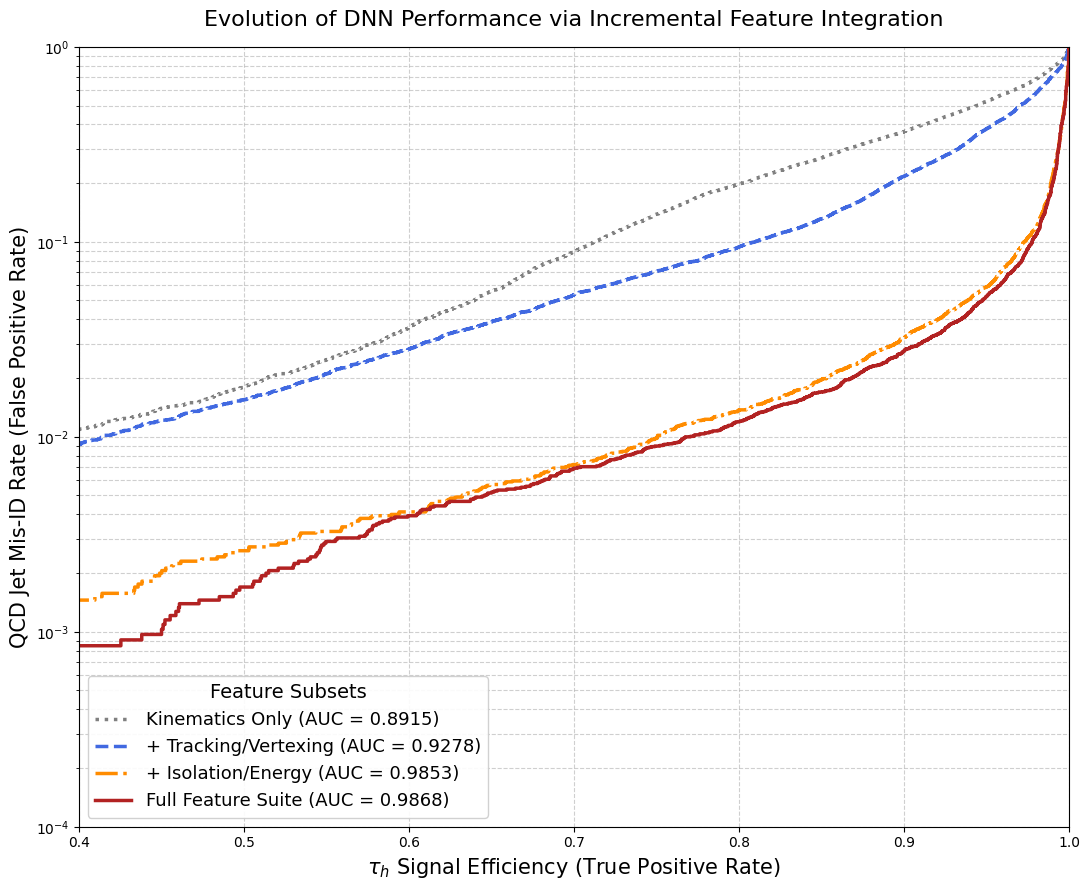

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(11, 9))

# Define a distinct color palette for the evolutionary steps
colors = ['gray', 'royalblue', 'darkorange', 'firebrick']
line_styles = [':', '--', '-.', '-']

# Plot each ROC curve from our stored dictionary
for (name, data), color, ls in zip(roc_results.items(), colors, line_styles):
    plt.plot(
        data['tpr'],
        data['fpr'],
        color=color,
        linestyle=ls,
        lw=2.5,
        label=f"{name} (AUC = {data['auc']:.4f})"
    )

# Formatting for CMS-style Physics Publications
plt.yscale('log')
plt.xlim([0.4, 1.0])
plt.ylim([1e-4, 1.0])

# Grid and Labels
plt.grid(True, which="both", ls="--", alpha=0.6)
plt.xlabel(r'$\tau_{h}$ Signal Efficiency (True Positive Rate)', fontsize=15)
plt.ylabel('QCD Jet Mis-ID Rate (False Positive Rate)', fontsize=15)
plt.title('Evolution of DNN Performance via Incremental Feature Integration', fontsize=16, pad=15)

# Legend Configuration
plt.legend(loc='lower left', fontsize=13, framealpha=0.9, title="Feature Subsets", title_fontsize=14)
plt.tight_layout()

# Render the graph
plt.show()